In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Making sure the plot shows up in the notebook
%matplotlib inline

# 1. Creating a daily date range for a year
date = pd.date_range(start="2023-01-01",periods=365, freq="D")

# 2. Building a base trend + weekly seasonality + noise
rng = np.random.default_rng(42)
n = len(date)

# Slowly increasing the baseline costs
base_trend = 50 + 0.05 * np.arange(n)

# Weekly pattern
weekly_seasonal = 8 * np.sin(2 * np.pi * np.arange(n) / 7)

# Random Fluctuations
noise = rng.normal(0, 3, size = n)

cost = base_trend + weekly_seasonal + noise

# 3. Injecting some big anomoly spikes in cost
anomalies_idx = [50, 120, 200, 260, 330]
multiplier = [2.5, 1.8, 2.2, 1.7, 2.8]

for i,m in zip(anomalies_idx, multiplier):
    cost[i]*=m

# 4. Building data frame
is_anomaly = np.zeros(n, dtype=bool)
is_anomaly[anomalies_idx] = True

df = pd.DataFrame({"date": date, "cost": cost, "is_anomaly": is_anomaly})

# 5. Saving a clean csv copy into data processed Folder
df.to_csv("../data_processed/synthetic_cloud_costs.csv", index = False)
df.head()

,date,cost,is_anomaly
0,2023-01-01,50.914151,False
1,2023-01-02,53.184700,False
2,2023-01-03,60.150777,False
3,2023-01-04,56.442764,False
4,2023-01-05,40.875825,False


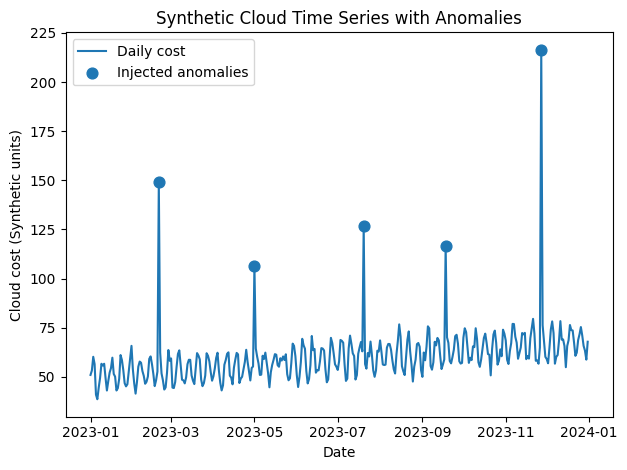

In [5]:
# Ploting

plt.Figure(figsize=(12,4))
plt.plot(df["date"], df["cost"], label="Daily cost")
plt.scatter(df.loc[df["is_anomaly"], "date"],
            df.loc[df["is_anomaly"], "cost"],
            marker="o", s=60, label="Injected anomalies")

plt.xlabel("Date")
plt.ylabel("Cloud cost (Synthetic units)")
plt.title("Synthetic Cloud Time Series with Anomalies")
plt.legend()
plt.tight_layout()
plt.show()

**Implementing Random Forest Model**

In [6]:
from sklearn.ensemble import IsolationForest

# Isolation Forest in general expects 2D input
X = df[["cost"]]

# Creating the model
iso_forest = IsolationForest(
    n_estimators=200,

    # roughly 2% anomalies
    contamination=0.02,
    random_state=42
)

# Fitting the model
iso_forest.fit(X)

# Predicting anomalies
# -1 = anomaly, 1 = normal
df["iforest_pred"] = iso_forest.predict(X)

# Convert to boolean for clarity
df["iforest_anomaly"] = df["iforest_pred"] == -1

df.head()


,date,cost,is_anomaly,iforest_pred,iforest_anomaly
0,2023-01-01,50.914151,False,1,False
1,2023-01-02,53.184700,False,1,False
2,2023-01-03,60.150777,False,1,False
3,2023-01-04,56.442764,False,1,False
4,2023-01-05,40.875825,False,-1,True


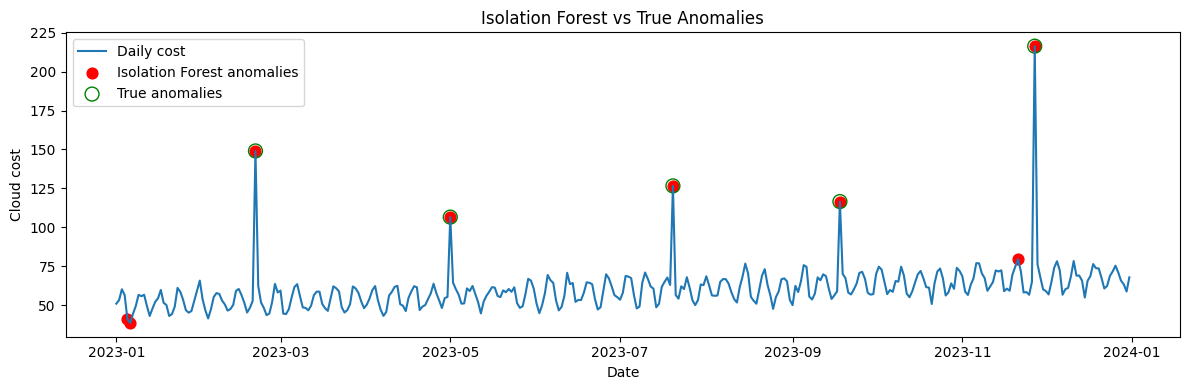

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["cost"], label="Daily cost")

plt.scatter(
    df.loc[df["iforest_anomaly"], "date"],
    df.loc[df["iforest_anomaly"], "cost"],
    color="red",
    s=60,
    label="Isolation Forest anomalies"
)

plt.scatter(
    df.loc[df["is_anomaly"], "date"],
    df.loc[df["is_anomaly"], "cost"],
    facecolors='none',
    edgecolors='green',
    s=100,
    label="True anomalies"
)

plt.xlabel("Date")
plt.ylabel("Cloud cost")
plt.title("Isolation Forest vs True Anomalies")
plt.legend()
plt.tight_layout()
plt.show()


**Quantifying Performance**

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

y_true = df["is_anomaly"]
y_pred = df["iforest_anomaly"]

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

precision, recall, f1


(0.625, 1.0, 0.7692307692307693)

**What happens if we change contimination, as it majorly affets the model**

In [12]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score

results = []

for contamination in [0.005, 0.01, 0.02, 0.05]:
    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42
    )
    model.fit(X)
    preds = model.predict(X) == -1

    results.append({
        "contamination": contamination,
        "precision": precision_score(y_true, preds),
        "recall": recall_score(y_true, preds)
    })

pd.DataFrame(results)


,contamination,precision,recall
0,0.005,1.000000,0.4
1,0.010,1.000000,0.8
2,0.020,0.625000,1.0
3,0.050,0.263158,1.0


**Z-score based anomaly detection**

In [13]:
mean_cost = df["cost"].mean()
std_cost = df["cost"].std()

# Z-score formula
df["z_score"] = (df["cost"] - mean_cost) / std_cost

# Threshold: 3 standard deviations
z_threshold = 3
df["z_anomaly"] = df["z_score"].abs() > z_threshold

df[["cost", "z_score", "z_anomaly"]].head()


,cost,z_score,z_anomaly
0,50.914151,-0.677378,False
1,53.184700,-0.510843,False
2,60.150777,0.000088,False
3,56.442764,-0.271878,False
4,40.875825,-1.413645,False


**Visualizing the Z-score anomalies**

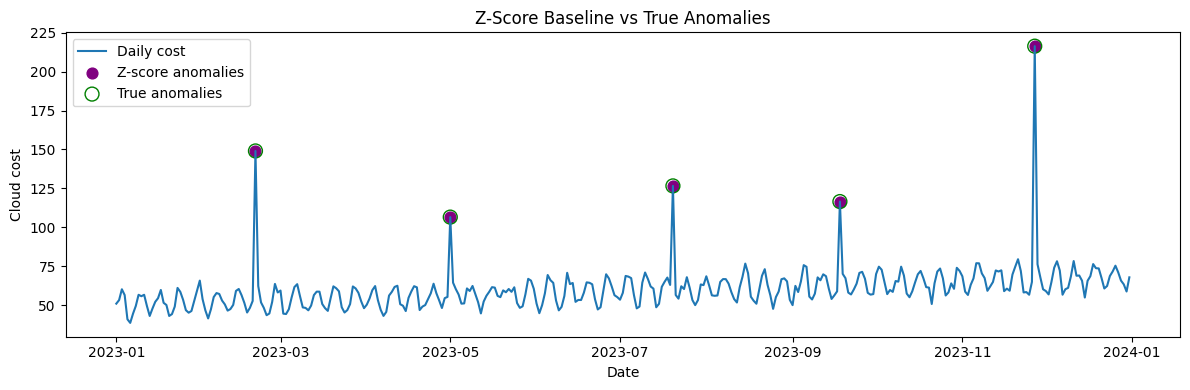

(1.0, 1.0, 1.0)

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["cost"], label="Daily cost")

plt.scatter(
    df.loc[df["z_anomaly"], "date"],
    df.loc[df["z_anomaly"], "cost"],
    color="purple",
    s=60,
    label="Z-score anomalies"
)

plt.scatter(
    df.loc[df["is_anomaly"], "date"],
    df.loc[df["is_anomaly"], "cost"],
    facecolors='none',
    edgecolors='green',
    s=100,
    label="True anomalies"
)

plt.xlabel("Date")
plt.ylabel("Cloud cost")
plt.title("Z-Score Baseline vs True Anomalies")
plt.legend()
plt.tight_layout()
plt.show()

# Evaluating performance of Z-score
precision_z = precision_score(y_true, df["z_anomaly"])
recall_z = recall_score(y_true, df["z_anomaly"])
f1_z = f1_score(y_true, df["z_anomaly"])

precision_z, recall_z, f1_z



**Comparision Table between Z-score and Isolation Forest**

In [17]:
comparison = pd.DataFrame({
    "Method": ["Z-score", "Isolation Forest"],
    "Precision": [precision_z, precision],
    "Recall": [recall_z, recall],
    "F1": [f1_z, f1]
})

comparison


,Method,Precision,Recall,F1
0,Z-score,1.000,1.0,1.000000
1,Isolation Forest,0.625,1.0,0.769231
